[![logo](https://raw.githubusercontent.com/ecmwf-training/2024-cams-act6-training/main/images/logoline.png)](https://atmosphere.copernicus.eu/6th-ecmwf-cams-esa-eumetsat-training-atmospheric-composition)

# Emissions

**Run the tutorial via free cloud platforms**: [![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/2024-cams-act6-training/main?labpath=04-emissions/emissions.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/2024-cams-act6-training/blob/main/04-emissions/emissions.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2024-cams-act6-training/blob/main/04-emissions/emissions.ipynb)

## Learning objectives

In this notebook we use the [cams-global-emission-inventories](https://ads.atmosphere.copernicus.eu/datasets/cams-global-emission-inventories) dataset. The dataset contains anthropogenic and natural emissions. We'll focus on nitrogen oxides (NOx). These come from several sources: agriculture, ships, power generation, road traffic, industry.

## Initial setup

Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the Climate Data Store (CDS), intalling any other packages not already installed, setting up our CDS API credentials and importing the various Python libraries that we will need.

In [58]:
# Ensure that the cdsapi package is installed
!pip install -q cdsapi
!pip install -q xarray
!pip install -q cartopy

In [59]:
# If you are running this notebook in Colab, uncomment the line below and run this cell.
#!pip install cartopy

### Add your ADS API credentials

To set up your ADS API credentials, please login/register on the [ADS](https://ads.atmosphere.copernicus.eu/), then you will see your [unique API key here](https://ads.atmosphere.copernicus.eu/how-to-api).

You can add this API key to your current session by replacing `#########` in the code cell below with your API key.

In [60]:
import os
os.environ['CDSAPI_URL'] = 'https://ads.atmosphere.copernicus.eu/api'
os.environ['CDSAPI_KEY'] = 'c155900d-4a53-436b-993c-de2aef0de188'

### Import libraries

In [61]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcol
from matplotlib.colors import ListedColormap
import calendar
from zipfile import ZipFile
import warnings
warnings.filterwarnings('ignore')

Here we specify a data directory in which we will download our data and all output files that we will generate:

In [62]:
lat_min, lat_max = 47, 55
lon_min, lon_max = 5, 16
def subset_germany(ds):
    return ds.sel(
        lat=slice(lat_min, lat_max),   # 47 → 55 (richtig!)
        lon=slice(lon_min, lon_max)
    )

In [63]:
DATADIR = '.'

## Explore and download data

Visit the download form for the [CAMS global emission inventories](https://ads.atmosphere.copernicus.eu/datasets/cams-global-emission-inventories) data. View the parameters in the API script in the following cell and select the corresponding options. For each year there will be a netcdf file inside the zip that will be downloaded. The size of the file for one year is 370 MB. The data is available from year 2000 up to 2020.

At the end of the download form, select **"Show API request"**. This will reveal a block of code, which should be identical to the code cell below.

**Please remember to accept the terms and conditions at the bottom of the download form.**


In [64]:
import cdsapi
c = cdsapi.Client()

In [65]:
dataset = "cams-global-emission-inventories"

years = ['2004', '2024']

for year in years:
    print(f"Downloading {year}...")

    request = {
        "variable": ["methane"],
        "source": ["anthropogenic"],
        "version": ["v5.3"],
        "year": [year],
    }

    c.retrieve(dataset, request).download(f"{DATADIR}/methane_{year}.zip")

2026-03-18 10:11:38,996 INFO Request ID is 630eff3a-bc6a-45a8-a54b-82fea388d44a
INFO:ecmwf.datastores.legacy_client:Request ID is 630eff3a-bc6a-45a8-a54b-82fea388d44a
2026-03-18 10:11:39,138 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-18 10:11:47,827 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


90597464b30663757bfb0a6bf5ed958b.zip:   0%|          | 0.00/422M [00:00<?, ?B/s]

2026-03-18 10:12:07,813 INFO Request ID is 72f24c8b-45ed-4acc-9379-0cea84bb595d
INFO:ecmwf.datastores.legacy_client:Request ID is 72f24c8b-45ed-4acc-9379-0cea84bb595d
2026-03-18 10:12:07,941 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-18 10:12:16,612 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-18 10:12:21,801 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


230f03f7794899303b83430837fce9bf.zip:   0%|          | 0.00/449M [00:00<?, ?B/s]

In [66]:
from zipfile import ZipFile

for year in years:
    zip_path = f"{DATADIR}/methane_{year}.zip"

    with ZipFile(zip_path, 'r') as zipObj:
        zipObj.extractall(path=f'{DATADIR}')

In [67]:
import os

for year in years:
    os.remove(f'{DATADIR}/methane_{year}.zip')

## Emissions of NOx from all sectors
The dataset of each year contains the emissions from 13 sectors for 12 months

In [68]:
def dataset_path(year_index):
    year = years[year_index]
    ds_path = f'{DATADIR}/CAMS-GLOB-ANT_v5.3_methane_{year}.nc'
    return ds_path

In [69]:
ch4_2004_ds_path = dataset_path(0)
ch4_2004_ds = xr.open_dataset(ch4_2004_ds_path, decode_times=False)
ch4_2004_ds = subset_germany(ch4_2004_ds)

In [70]:
ch4_2024_ds_path = dataset_path(1)
ch4_2024_ds = xr.open_dataset(ch4_2024_ds_path, decode_times=False)
ch4_2024_ds = subset_germany(ch4_2024_ds)

## NOx all sectors
We sum the emissions from all sectors in one year. We create a new data array to store the sum of the values from each sector in one year.

In [83]:
def create_da(ds):
    '''
    Erstellt ein leeres DataArray (mit Nullen) basierend auf einem
    vorhandenen Datensatz. Wird später genutzt, um Werte über
    verschiedene Sektoren zu summieren.
    '''

    # Dimensionen
    months = ds.time
    lats = ds.lat
    lons = ds.lon

    zeros3d = np.zeros((len(months), len(lats), len(lons)), dtype=np.float32)

    # Koordinaten
    coords = [months, lats, lons]

    output_da = xr.DataArray(
        zeros3d,
        coords=coords,
        dims=['time', 'lat', 'lon']
    )

    # 👉 WICHTIG: richtige Variable automatisch finden
    var_name = list(ds.data_vars)[0]

    # Attribute übernehmen (sicher)
    output_da.attrs['long_name'] = 'Sum of all emissions'
    output_da.attrs['units'] = ds[var_name].attrs.get('units', 'unknown')
    output_da.attrs['sector_name'] = 'all sectors'
    output_da.attrs['standard_name'] = 'no standard name'

    return output_da

We loop through all the sectors and months to sum up the values from each sector for each month

In [84]:
def sum_all_sectors(ds):
    vars_to_sum = [ds[var] for var in ds.data_vars if var != "sum"]
    return xr.concat(vars_to_sum, dim="sector").sum(dim="sector")
    '''
    Summiert alle Emissionen über alle Sektoren
    und gibt ein DataArray zurück
    '''

    # Alle Variablen aufsummieren
    total = sum(ds[var] for var in ds.data_vars)

    # Attribute setzen (optional)
    total.attrs['long_name'] = 'Sum of all emissions'
    total.attrs['sector_name'] = 'all sectors'

    return total

### NOx from all sectors in 2000

In [85]:
for var in ch4_2004_ds.data_vars:
    print(var, float(ch4_2004_ds[var].mean()))

agl 1.1287406426196966e-10
ags 0.0
awb 3.7634075001312384e-13
ene 6.206522383707391e-13
fef 0.0
fef_coal 1.3620049532647727e-11
fef_gas 2.3205841762075075e-11
fef_oil 3.0766906492125934e-13
ind 8.944824590219336e-13
ref 1.1220723785884679e-12
res 6.564790811652843e-12
sum 2.724705183698717e-10
swd 1.1179648179426849e-10
tnr 7.655675206730446e-15
tro 1.0818767756659575e-12


In [86]:
ch4_2004_all_sectors_da = sum_all_sectors(ch4_2004_ds)
ch4_2004_all_sectors_da

<xarray.DataArray 'agl' (time: 12, lat: 80, lon: 110)> Size: 422kB
array([[[8.39465858e-11, 1.12988473e-10, 8.63035823e-11, ...,
         6.88061413e-11, 7.21896848e-11, 7.80068440e-11],
        [8.29899066e-11, 9.51248316e-11, 7.27525540e-11, ...,
         6.16061230e-11, 4.71112212e-11, 5.57884780e-11],
        [1.70978134e-10, 1.16625418e-10, 9.46154544e-11, ...,
         5.43304707e-11, 5.57584499e-11, 6.98948954e-11],
        ...,
        [1.27302465e-12, 1.02121762e-12, 9.23295078e-13, ...,
         2.51805873e-13, 2.37817768e-13, 2.23829947e-13],
        [7.85340759e-13, 1.06582180e-12, 6.31078252e-13, ...,
         9.81672629e-14, 8.41437651e-14, 2.80480104e-14],
        [3.93645864e-13, 5.06118856e-13, 3.37411495e-13, ...,
         2.81174823e-14, 7.02941530e-14, 9.84122858e-14]],

       [[3.16607955e-11, 5.42809409e-11, 4.02620229e-11, ...,
         5.95859126e-11, 6.32767519e-11, 6.83511719e-11],
        [3.14087679e-11, 4.83043154e-11, 3.62444276e-11, ...,
         5.27205744e-11, 3.76490714e-11, 4.79139679e-11],
        [1.43087861e-10, 8.72981548e-11, 5.25650530e-11, ...,
         4.35264880e-11, 4.47104367e-11, 5.94550034e-11],
...
        [1.27302465e-12, 1.02121762e-12, 9.23295078e-13, ...,
         2.51805873e-13, 2.37817768e-13, 2.23829947e-13],
        [7.85340759e-13, 1.06582180e-12, 6.31078252e-13, ...,
         9.81672629e-14, 8.41437651e-14, 2.80480104e-14],
        [3.93645864e-13, 5.06118856e-13, 3.37411495e-13, ...,
         2.81174823e-14, 7.02941530e-14, 9.84122858e-14]],

       [[1.86685709e-10, 2.28431468e-10, 1.76942377e-10, ...,
         6.22202428e-11, 6.61837529e-11, 7.09936415e-11],
        [1.84337490e-10, 1.87196064e-10, 1.44715281e-10, ...,
         5.52990084e-11, 4.01071711e-11, 4.90398416e-11],
        [2.24746388e-10, 1.73781406e-10, 1.77005868e-10, ...,
         4.37820960e-11, 4.49823095e-11, 5.99800973e-11],
        ...,
        [1.27302465e-12, 1.02121762e-12, 9.23295078e-13, ...,
         2.51805873e-13, 2.37817768e-13, 2.23829947e-13],
        [7.85340759e-13, 1.06582180e-12, 6.31078252e-13, ...,
         9.81672629e-14, 8.41437651e-14, 2.80480104e-14],
        [3.93645864e-13, 5.06118856e-13, 3.37411495e-13, ...,
         2.81174823e-14, 7.02941530e-14, 9.84122858e-14]]], dtype=float32)
Coordinates:
  * time     (time) float32 48B 1.35e+06 1.351e+06 ... 1.357e+06 1.358e+06
  * lat      (lat) float32 320B 47.05 47.15 47.25 47.35 ... 54.75 54.85 54.95
  * lon      (lon) float32 440B 5.05 5.15 5.25 5.35 ... 15.65 15.75 15.85 15.95
Attributes:
    units:             kg m-2 s-1
    sector_name:       Agriculture livestock (mma)
    standard_name:     tendency_of_atmosphere_mass_content_of_ch4_due_to_emis...
    cell_method:       time: sum (interval: 1 month comment: gregorian calend...
    molecular_weight:  16
    long_name:         Emissions of CH4 for agl sector

### NOx from all sectors in 2020

In [87]:
print(ch4_2004_ds)

<xarray.Dataset> Size: 6MB
Dimensions:   (time: 12, lat: 80, lon: 110)
Coordinates:
  * time      (time) float32 48B 1.35e+06 1.351e+06 ... 1.357e+06 1.358e+06
  * lat       (lat) float32 320B 47.05 47.15 47.25 47.35 ... 54.75 54.85 54.95
  * lon       (lon) float32 440B 5.05 5.15 5.25 5.35 ... 15.65 15.75 15.85 15.95
Data variables: (12/15)
    agl       (time, lat, lon) float32 422kB 6.829e-11 7.573e-11 ... 0.0 0.0
    ags       (time, lat, lon) float32 422kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    awb       (time, lat, lon) float32 422kB 7.444e-13 1.51e-12 ... 0.0 0.0
    ene       (time, lat, lon) float32 422kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    fef       (time, lat, lon) float32 422kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    fef_coal  (time, lat, lon) float32 422kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...        ...
    ref       (time, lat, lon) float32 422kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    res       (time, lat, lon) float32 422kB 3.16e-12 9.105e-12 ... 0.0 0.0
   

In [88]:
ch4_2024_all_sectors_da = sum_all_sectors(ch4_2024_ds)
ch4_2024_all_sectors_da

<xarray.DataArray 'agl' (time: 12, lat: 80, lon: 110)> Size: 422kB
array([[[8.00645661e-11, 1.06768920e-10, 8.17273194e-11, ...,
         7.96832045e-11, 8.16819737e-11, 8.83138146e-11],
        [8.36855238e-11, 9.51535101e-11, 7.06138134e-11, ...,
         7.18260312e-11, 4.97569659e-11, 6.68792452e-11],
        [1.53681123e-10, 1.08701978e-10, 9.06586056e-11, ...,
         5.29896231e-11, 5.47676106e-11, 7.15044204e-11],
        ...,
        [2.10075663e-12, 1.51255744e-12, 1.05513558e-12, ...,
         6.42087620e-13, 6.20816766e-13, 6.43653316e-13],
        [7.79077595e-13, 1.92619011e-12, 1.57328415e-12, ...,
         9.73844689e-14, 8.34726710e-14, 1.44017421e-13],
        [1.29014095e-12, 5.04141542e-13, 1.10866828e-12, ...,
         2.78933489e-14, 6.97338238e-14, 9.76275403e-14]],

       [[2.85966563e-11, 4.78717274e-11, 3.47062656e-11, ...,
         6.57758709e-11, 6.89911600e-11, 7.53775861e-11],
        [3.13051009e-11, 4.66901136e-11, 3.14960766e-11, ...,
         5.85580542e-11, 3.73501716e-11, 5.75056634e-11],
        [1.22451396e-10, 7.69040248e-11, 4.76910005e-11, ...,
         4.26537486e-11, 4.41179107e-11, 6.06234507e-11],
...
        [1.47631885e-12, 1.13446741e-12, 1.18568653e-12, ...,
         4.69449132e-13, 3.86414262e-13, 3.55672306e-13],
        [7.79077595e-13, 1.38136009e-12, 8.05814020e-13, ...,
         9.73844689e-14, 1.18783835e-13, 2.78244343e-14],
        [4.46071511e-13, 5.02084106e-13, 5.70893213e-13, ...,
         2.78933489e-14, 6.97338238e-14, 9.76275403e-14]],

       [[1.78884130e-10, 2.16703558e-10, 1.67481390e-10, ...,
         7.22175791e-11, 7.50753348e-11, 8.03589556e-11],
        [1.80298027e-10, 1.82222876e-10, 1.37083817e-10, ...,
         6.46980663e-11, 4.23169902e-11, 5.97133801e-11],
        [2.01798495e-10, 1.60998395e-10, 1.68053835e-10, ...,
         4.76554525e-11, 4.97089904e-11, 6.51157045e-11],
        ...,
        [2.04110969e-12, 1.30522719e-12, 2.14724354e-12, ...,
         3.26842557e-13, 3.06719494e-13, 2.80716043e-13],
        [1.38973306e-12, 1.76867744e-12, 1.36257433e-12, ...,
         9.73844689e-14, 9.46309071e-14, 4.49404579e-14],
        [3.90507830e-13, 1.21756880e-12, 7.48477181e-13, ...,
         2.78933489e-14, 6.97338238e-14, 9.76275403e-14]]], dtype=float32)
Coordinates:
  * time     (time) int32 48B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float32 320B 47.05 47.15 47.25 47.35 ... 54.75 54.85 54.95
  * lon      (lon) float32 440B 5.05 5.15 5.25 5.35 ... 15.65 15.75 15.85 15.95
Attributes:
    units:             kg m-2 s-1
    sector_name:       Agriculture livestock (mma)
    cell_method:       time: sum (interval: 1 month comment: gregorian calend...
    molecular_weight:  16.0
    long_name:         Emissions of CH4 for agl sector

## Visualizations
We plot the data for the sum of emission from all sectors for each month. We define a discrete color map to visualize the values in the map.

In [89]:
dark_red = '#971039'
red = '#D93322'
orange = '#F09235'
dark_yellow = '#F5BE41'
yellow = '#ECD347'
light_yellow = '#FFFF00'
green = '#5AAA5F'
light_green = '#A7D25C'
cyan = '#7EFEE7'
light_blue = '#92D2F9'
blue = '#0B2CA1'
white = '#FFFFFF'
colors = [white, blue, light_blue, cyan, light_green, green, light_yellow, yellow, dark_yellow, orange, red, dark_red]
levels = [4e-18, 4e-17, 4e-16, 4e-15, 4e-14, 4e-13, 4e-12, 4e-11, 4e-10, 4e-9, 4e-8, 4e-7]
#level_ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
emissions_cmap = ListedColormap(colors)

In [90]:
calendar.month_name[1]

'January'

In [91]:
def plot_emissions(da, year, month):

    # 👉 Deutschland-Ausschnitt
    lonmin, lonmax = 5, 16
    latmin, latmax = 47, 55

    plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.gridlines(draw_labels=True, linestyle='--')
    ax.add_feature(cartopy.feature.LAND, edgecolor='black')
    ax.coastlines()

    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

    # 👉 WICHTIG: isel + month verwenden
    da_plt = da.isel(time=month).plot(
        ax=ax,
        add_colorbar=False,
        cmap='YlOrRd',
        robust=True
    )

    cbar = plt.colorbar(da_plt, fraction=0.025, pad=0.05)
    cbar.set_label('kg m$^{-2}$ s$^{-1}$')

    plt.title(f'CH₄ Emissionen Deutschland – {calendar.month_name[month+1]} {year}')

    plt.show()

In [109]:
import calendar
import numpy as np
from matplotlib.colors import LogNorm

def plot_emissions(da, year, month):

    print("Plot läuft...")

    lonmin, lonmax = 5, 16
    latmin, latmax = 47, 55

    plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.LambertConformal(
    central_longitude=10,
    central_latitude=51,
    standard_parallels=(47, 55)
))

    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS, linewidth=1)

    # 🔥 FIX 1: CRS hinzufügen
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

    da_plot = da.where(da > 0)

    vmin = float(np.nanpercentile(da_plot, 10))
    vmax = float(np.nanpercentile(da_plot, 99))

    da_plt = da_plot.isel(time=month).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),   # 🔥 FIX 2: GANZ WICHTIG
        add_colorbar=False,
        cmap='YlOrRd',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    plt.colorbar(da_plt, fraction=0.025, pad=0.05)

    plt.title(f'{year} – {calendar.month_name[month+1]}')
    plt.show()

Plot läuft...


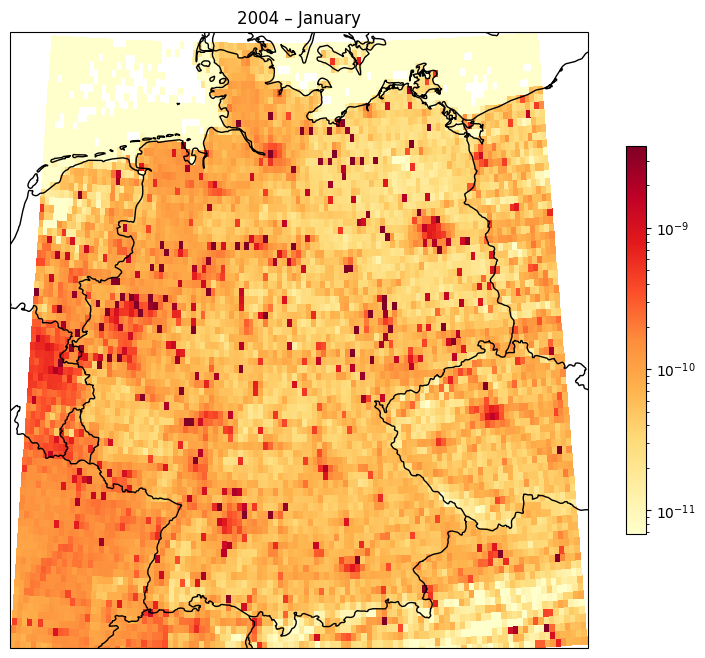

In [110]:
plot_emissions(ch4_total_2004, '2004', 0)

Plot läuft...


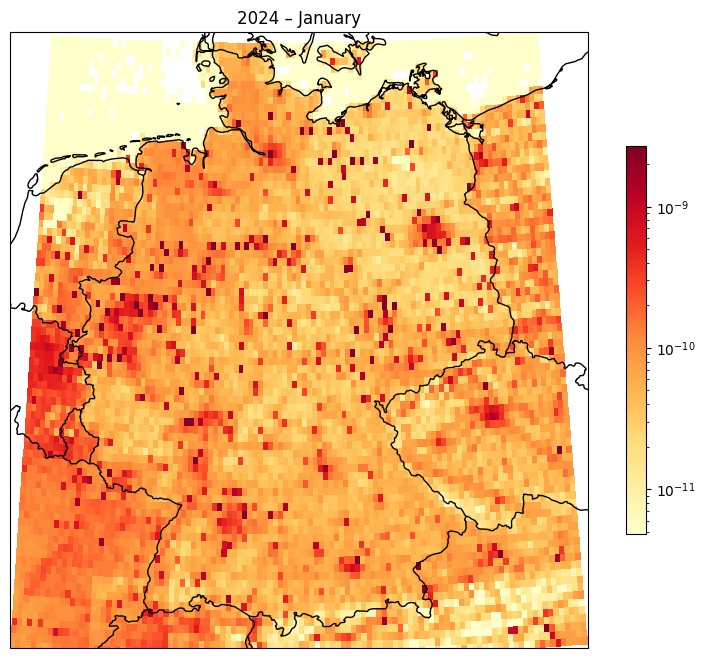

In [111]:
plot_emissions(ch4_2024_all_sectors_da, '2024', 0)

### Total flux January-December

In [113]:
tot_ch4_2024 = ch4_total_2024.sum(dim='time')

In [116]:
def plot_total_emissions(da, year):

    lonmin, lonmax = 5, 16
    latmin, latmax = 47, 55

    plt.figure(figsize=(10,8))
    ax = plt.axes(projection=ccrs.LambertConformal(
        central_longitude=10,
        central_latitude=51,
        standard_parallels=(47, 55)
    ))

    ax.add_feature(cartopy.feature.LAND, edgecolor='black')
    ax.add_feature(cartopy.feature.BORDERS, linewidth=1)
    ax.coastlines()

    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

    from matplotlib.colors import LogNorm
    import numpy as np

    da_plot = da.where(da > 0)

    vmin = float(np.nanpercentile(da_plot, 10))
    vmax = float(np.nanpercentile(da_plot, 99))

    da_plt = da_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        cmap='YlOrRd',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    cbar = plt.colorbar(da_plt, fraction=0.025, pad=0.05)
    cbar.set_label('Emissionen (kg m$^{-2}$ s$^{-1}$)')

    plt.title(f'Gesamtemissionen Deutschland – {year}')

    plt.show()

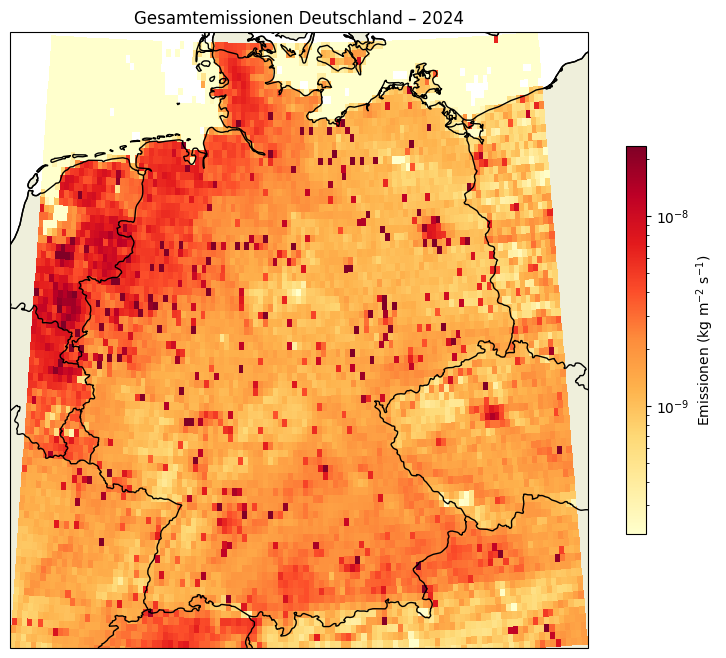

In [117]:
plot_total_emissions(tot_ch4_2024, '2024')

## Total flux for 2000 and 2020
We calculate the total emissions from all sector for each year

In [121]:
tot_ch4_2004 = ch4_total_2004.sum(dim='time')   # Karte
total_2004 = float(tot_ch4_2004.sum())          # Zahl

In [124]:
tot_ch4_2024 = ch4_total_2024.sum(dim='time')   # Karte
total_2024 = float(tot_ch4_2024.sum())          # Zahl

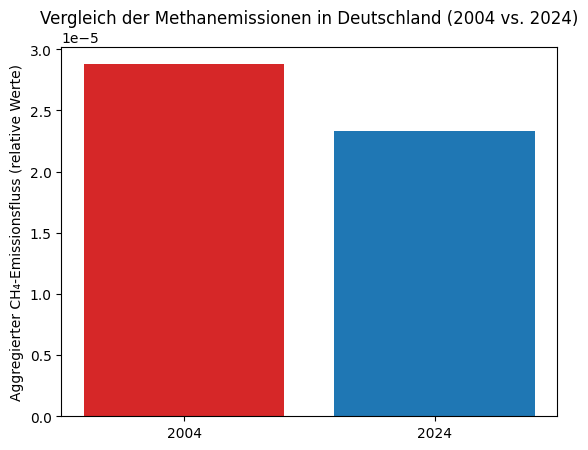

In [128]:
fig, ax = plt.subplots()

tot_emissions = [total_2004, total_2024]
years = ['2004', '2024']
bar_colors = ['tab:red', 'tab:blue']

ax.bar(years, tot_emissions, color=bar_colors)

ax.set_ylabel('Aggregierter CH₄-Emissionsfluss (relative Werte)')
ax.set_title('Vergleich der Methanemissionen in Deutschland (2004 vs. 2024)')

plt.show()